# CUAD Category Tier Definition Report

## Motivation

ContractEval (Liu et al., 2025) informally refers to certain clause categories as "rare" based on visual inspection of their Figure 4, but never:

1. **Counts** positive samples per category in the dataset
2. **Defines** a quantitative threshold for common vs. rare
3. **Stratifies** aggregate metrics by frequency tier

The current `CATEGORY_TIERS` in `cuad_loader.py` mirrors this approach — tiers are assigned based on ContractEval's GPT-4 F1 scores, which conflate **dataset prevalence** (an intrinsic property) with **model performance** (an extrinsic property). A category could have high prevalence but low F1 due to extraction difficulty, or low prevalence but high F1 due to simple patterns.

This notebook formally defines tiers using **positive rate (prevalence)** — a dataset-intrinsic, model-independent property — and compares the result against the current F1-based tiers.

## 1. Load Data

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

from src.data import CUADDataLoader, CATEGORY_TIERS, get_category_tier

loader = CUADDataLoader()
loader.load()

stats = loader.stats()
print(f"Loaded {stats['total_samples']:,} samples across {stats['num_contracts']} contracts and {stats['num_categories']} categories")
print(f"Positive: {stats['positive_samples']:,} ({stats['positive_rate']:.1%}) | Negative: {stats['negative_samples']:,}")

Loaded 20,910 samples across 510 contracts and 41 categories
Positive: 6,702 (32.1%) | Negative: 14,208


## 2. Per-Category Statistics

In [2]:
rows = []
for cat in sorted(loader.get_categories()):
    samples = loader.get_by_category(cat)
    positives = [s for s in samples if s.has_clause]
    pos_count = len(positives)
    pos_rate = pos_count / len(samples)
    
    # Average spans per positive sample
    avg_spans = np.mean([s.num_spans for s in positives]) if positives else 0.0
    
    # Average clause length (chars) across all spans of positive samples
    all_span_lengths = [len(span) for s in positives for span in s.ground_truth_spans]
    avg_clause_len = np.mean(all_span_lengths) if all_span_lengths else 0.0
    
    rows.append({
        "category": cat,
        "positive_count": pos_count,
        "total": len(samples),
        "positive_rate": pos_rate,
        "avg_spans": avg_spans,
        "avg_clause_length": avg_clause_len,
        "f1_tier": get_category_tier(cat),  # current F1-based tier
    })

df = pd.DataFrame(rows).sort_values("positive_rate", ascending=False).reset_index(drop=True)
df.index = df.index + 1  # 1-based ranking
df.index.name = "rank"

print(f"Total positives across all categories: {df['positive_count'].sum():,}")
print(f"Categories: {len(df)}")
print()
df[["category", "positive_count", "positive_rate", "avg_spans", "avg_clause_length", "f1_tier"]]

Total positives across all categories: 6,702
Categories: 41



,category,positive_count,positive_rate,avg_spans,avg_clause_length,f1_tier
rank,,,,,,
1,Document Name,510,1.000000,1.021569,29.817658,common
2,Parties,509,0.998039,5.017682,23.569303,common
3,Agreement Date,470,0.921569,1.012766,18.197479,common
4,Governing Law,437,0.856863,1.061785,206.202586,common
5,Expiration Date,413,0.809804,1.130751,230.695931,common
6,Effective Date,390,0.764706,1.146154,62.163311,common
7,Anti-Assignment,374,0.733333,1.748663,293.139144,moderate
8,Cap On Liability,275,0.539216,2.443636,376.764881,moderate
9,License Grant,255,0.500000,3.047059,432.091377,moderate


## 3. Distribution Visualization

Horizontal bar chart of positive rates, sorted descending, with proposed prevalence-based tier thresholds overlaid.

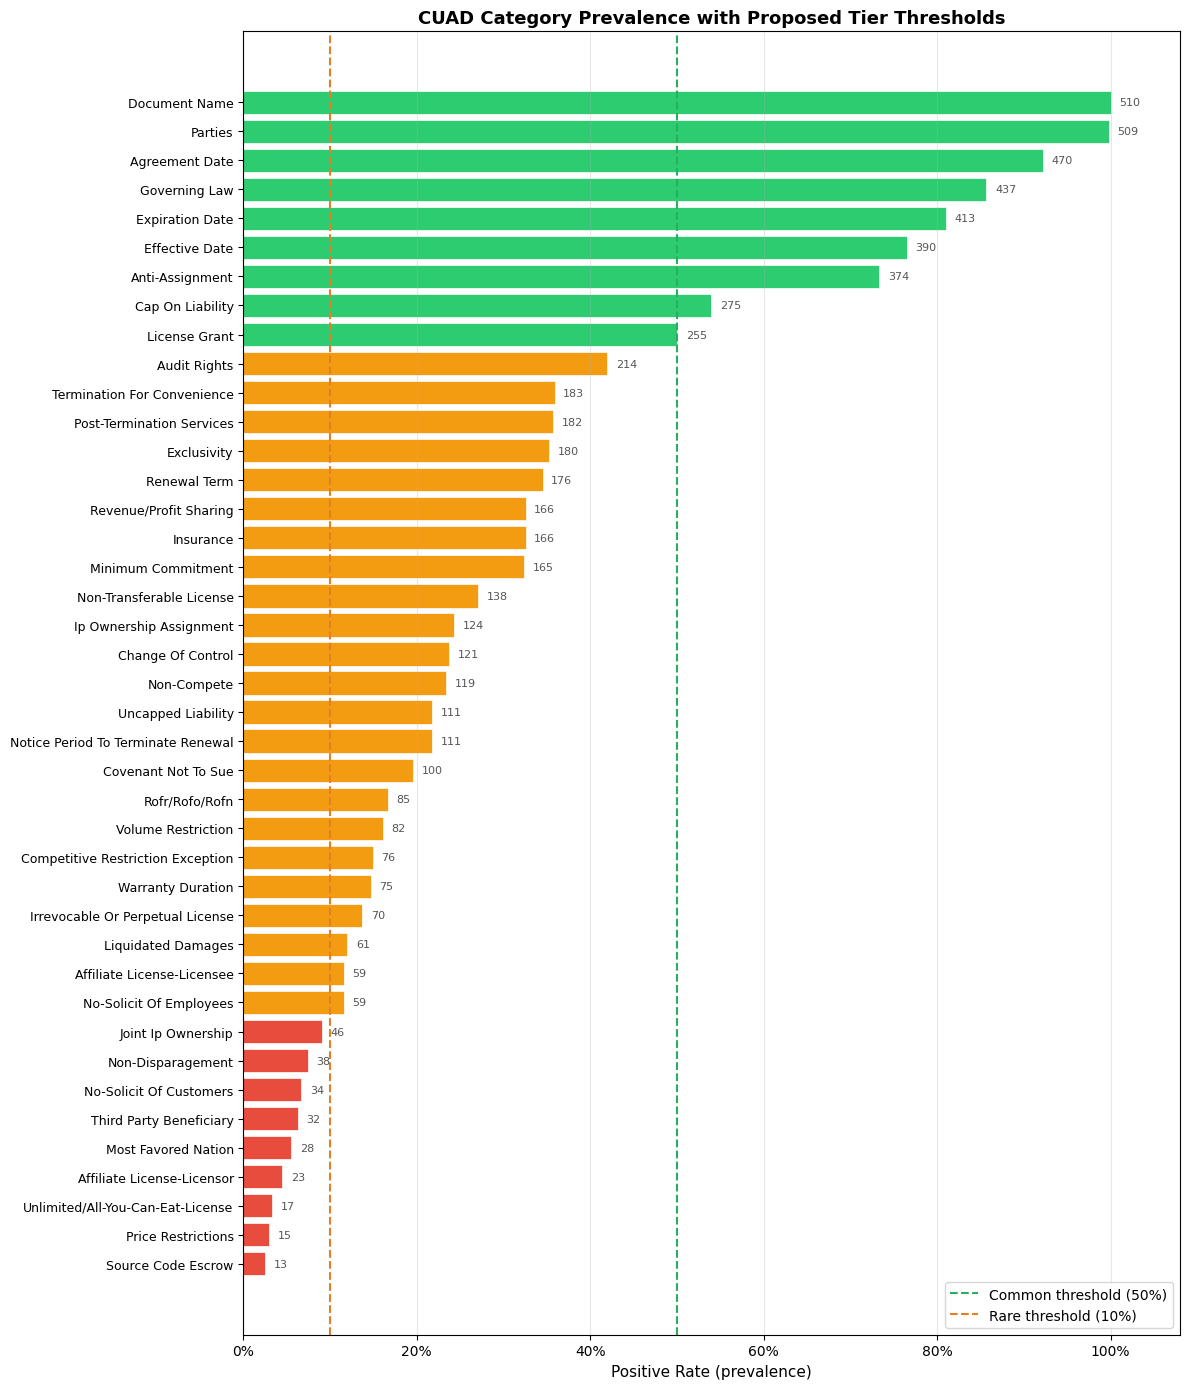

Saved: outputs/category_prevalence_chart.png


In [3]:
# Tier thresholds (positive rate)
COMMON_THRESHOLD = 0.50   # >= 50%
MODERATE_THRESHOLD = 0.10  # >= 10%
# < 10% = rare

def assign_prevalence_tier(rate: float) -> str:
    if rate >= COMMON_THRESHOLD:
        return "common"
    elif rate >= MODERATE_THRESHOLD:
        return "moderate"
    else:
        return "rare"

df["prevalence_tier"] = df["positive_rate"].apply(assign_prevalence_tier)

TIER_COLORS = {"common": "#2ecc71", "moderate": "#f39c12", "rare": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 14))

# Plot bars
plot_df = df.sort_values("positive_rate", ascending=True)
colors = [TIER_COLORS[t] for t in plot_df["prevalence_tier"]]
bars = ax.barh(range(len(plot_df)), plot_df["positive_rate"], color=colors, edgecolor="white", linewidth=0.5)

# Labels
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["category"], fontsize=9)
ax.set_xlabel("Positive Rate (prevalence)", fontsize=11)
ax.set_title("CUAD Category Prevalence with Proposed Tier Thresholds", fontsize=13, fontweight="bold")

# Threshold lines
ax.axvline(x=COMMON_THRESHOLD, color="#27ae60", linestyle="--", linewidth=1.5, label=f"Common threshold ({COMMON_THRESHOLD:.0%})")
ax.axvline(x=MODERATE_THRESHOLD, color="#e67e22", linestyle="--", linewidth=1.5, label=f"Rare threshold ({MODERATE_THRESHOLD:.0%})")

# Add count annotations
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["positive_rate"] + 0.01, i, f"{row['positive_count']}", va="center", fontsize=8, color="#555")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 1.08)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/category_prevalence_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/category_prevalence_chart.png")

## 4. Proposed Prevalence-Based Tier Definition

We define tiers using **positive rate (prevalence)** — a dataset-intrinsic property independent of any model's performance:

| Tier | Criterion | Positive Rate | Rationale |
|------|-----------|---------------|----------|
| **Common** | Appears in majority of contracts | >= 50% (>= 255/510) | Standard contractual elements present in most agreements |
| **Moderate** | Appears in a meaningful minority | 10%--50% (51--254/510) | Domain-specific clauses that appear regularly but not universally |
| **Rare** | Appears in fewer than 1 in 10 contracts | < 10% (<= 50/510) | Specialized clauses found only in specific deal types |

**Why these thresholds:**
- **50%** = natural majority boundary; categories above this appear in most contracts
- **10%** = standard statistical rarity threshold; below this, models have very few positive training examples
- Both are round, interpretable percentages that align with natural gaps visible in the distribution above

## 5. Tier Assignment Table

In [4]:
for tier in ["common", "moderate", "rare"]:
    tier_df = df[df["prevalence_tier"] == tier].copy()
    n = len(tier_df)
    total_pos = tier_df["positive_count"].sum()
    rate_range = f"{tier_df['positive_rate'].min():.1%} -- {tier_df['positive_rate'].max():.1%}"
    
    print(f"\n{'='*70}")
    print(f"{tier.upper()} ({n} categories, {total_pos:,} total positives, range: {rate_range})")
    print(f"{'='*70}")
    print(f"{'Category':<42} {'Pos':<6} {'Rate':<8} {'Spans':<7} {'Len':<8} {'F1 Tier'}")
    print("-" * 70)
    for _, row in tier_df.iterrows():
        changed = " *" if row["f1_tier"] != tier else ""
        print(f"{row['category']:<42} {row['positive_count']:<6} {row['positive_rate']:<8.1%} {row['avg_spans']:<7.1f} {row['avg_clause_length']:<8.0f} {row['f1_tier']}{changed}")


COMMON (9 categories, 3,633 total positives, range: 50.0% -- 100.0%)
Category                                   Pos    Rate     Spans   Len      F1 Tier
----------------------------------------------------------------------
Document Name                              510    100.0%   1.0     30       common
Parties                                    509    99.8%    5.0     24       common
Agreement Date                             470    92.2%    1.0     18       common
Governing Law                              437    85.7%    1.1     206      common
Expiration Date                            413    81.0%    1.1     231      common
Effective Date                             390    76.5%    1.1     62       common
Anti-Assignment                            374    73.3%    1.7     293      moderate *
Cap On Liability                           275    53.9%    2.4     377      moderate *
License Grant                              255    50.0%    3.0     432      moderate *

MODERATE (23 ca

## 6. Comparison: Prevalence-Based vs. F1-Based Tiers

Categories that **change tier** between the two definitions reveal where dataset prevalence and model performance diverge.

In [5]:
df["tier_changed"] = df["f1_tier"] != df["prevalence_tier"]
changed = df[df["tier_changed"]].copy()

print(f"{len(changed)} of {len(df)} categories change tier\n")
print(f"{'Category':<42} {'F1 Tier':<12} {'Prev. Tier':<12} {'Pos Rate':<10} {'Reason'}")
print("=" * 95)

for _, row in changed.iterrows():
    # Determine reason
    if row["f1_tier"] == "rare" and row["prevalence_tier"] == "moderate":
        reason = "High prevalence but low F1 -> extraction is hard, not rare"
    elif row["f1_tier"] == "moderate" and row["prevalence_tier"] == "rare":
        reason = "Low prevalence but moderate F1 -> easy pattern, but infrequent"
    elif row["f1_tier"] == "moderate" and row["prevalence_tier"] == "common":
        reason = "Very high prevalence but moderate F1 -> common but tricky"
    elif row["f1_tier"] == "common" and row["prevalence_tier"] == "moderate":
        reason = "Moderate prevalence but high F1 -> easy to extract"
    else:
        reason = f"{row['f1_tier']} -> {row['prevalence_tier']}"
    
    print(f"{row['category']:<42} {row['f1_tier']:<12} {row['prevalence_tier']:<12} {row['positive_rate']:<10.1%} {reason}")

13 of 41 categories change tier

Category                                   F1 Tier      Prev. Tier   Pos Rate   Reason
Anti-Assignment                            moderate     common       73.3%      Very high prevalence but moderate F1 -> common but tricky
Cap On Liability                           moderate     common       53.9%      Very high prevalence but moderate F1 -> common but tricky
License Grant                              moderate     common       50.0%      Very high prevalence but moderate F1 -> common but tricky
Revenue/Profit Sharing                     rare         moderate     32.5%      High prevalence but low F1 -> extraction is hard, not rare
Minimum Commitment                         rare         moderate     32.4%      High prevalence but low F1 -> extraction is hard, not rare
Uncapped Liability                         rare         moderate     21.8%      High prevalence but low F1 -> extraction is hard, not rare
Notice Period To Terminate Renewal         rare  

In [6]:
# Confusion matrix: F1-based vs prevalence-based
tier_order = ["common", "moderate", "rare"]
confusion = pd.crosstab(
    pd.Categorical(df["f1_tier"], categories=tier_order, ordered=True),
    pd.Categorical(df["prevalence_tier"], categories=tier_order, ordered=True),
    rownames=["F1-based tier"],
    colnames=["Prevalence-based tier"]
)

print("Tier Reclassification Matrix")
print("(rows = current F1-based, columns = proposed prevalence-based)\n")
print(confusion)
print(f"\nAgreement: {(df['f1_tier'] == df['prevalence_tier']).sum()}/{len(df)} ({(df['f1_tier'] == df['prevalence_tier']).mean():.0%})")

Tier Reclassification Matrix
(rows = current F1-based, columns = proposed prevalence-based)

Prevalence-based tier  common  moderate  rare
F1-based tier                                
common                      6         0     0
moderate                    3        14     1
rare                        0         9     8

Agreement: 28/41 (68%)


## 7. Tier Summary Statistics

In [7]:
summary_rows = []
for tier in ["common", "moderate", "rare"]:
    tier_df = df[df["prevalence_tier"] == tier]
    summary_rows.append({
        "Tier": tier.capitalize(),
        "Categories": len(tier_df),
        "Total Positives": tier_df["positive_count"].sum(),
        "Avg Positive Rate": tier_df["positive_rate"].mean(),
        "Min Rate": tier_df["positive_rate"].min(),
        "Max Rate": tier_df["positive_rate"].max(),
        "Avg Spans/Positive": tier_df["avg_spans"].mean(),
        "Avg Clause Length": tier_df["avg_clause_length"].mean(),
    })

# Add total row
summary_rows.append({
    "Tier": "TOTAL",
    "Categories": len(df),
    "Total Positives": df["positive_count"].sum(),
    "Avg Positive Rate": df["positive_rate"].mean(),
    "Min Rate": df["positive_rate"].min(),
    "Max Rate": df["positive_rate"].max(),
    "Avg Spans/Positive": df["avg_spans"].mean(),
    "Avg Clause Length": df["avg_clause_length"].mean(),
})

summary = pd.DataFrame(summary_rows).set_index("Tier")
summary["Avg Positive Rate"] = summary["Avg Positive Rate"].map("{:.1%}".format)
summary["Min Rate"] = summary["Min Rate"].map("{:.1%}".format)
summary["Max Rate"] = summary["Max Rate"].map("{:.1%}".format)
summary["Avg Spans/Positive"] = summary["Avg Spans/Positive"].map("{:.1f}".format)
summary["Avg Clause Length"] = summary["Avg Clause Length"].map("{:.0f}".format)

print("Prevalence-Based Tier Summary")
print("=" * 80)
summary

Prevalence-Based Tier Summary


,Categories,Total Positives,Avg Positive Rate,Min Rate,Max Rate,Avg Spans/Positive,Avg Clause Length
Tier,,,,,,,
Common,9,3633,79.2%,50.0%,100.0%,2.0,186
Moderate,23,2823,24.1%,11.6%,42.0%,2.2,380
Rare,9,246,5.4%,2.5%,9.0%,2.3,398
TOTAL,41,6702,32.1%,2.5%,100.0%,2.2,342


## 8. Discussion

### Key Findings

**1. Prevalence and performance are correlated but not identical.**  
Most categories that are "common" by prevalence are also "common" by F1, and most "rare" by prevalence are also "rare" by F1. However, several categories diverge — revealing that extraction difficulty is not purely a function of how often a clause appears.

**2. Notable reclassifications:**
- **Revenue/Profit Sharing** and **Minimum Commitment** (~32% prevalence each) are currently labeled "rare" based on near-zero F1, but are actually moderately prevalent. Their poor F1 reflects extraction difficulty, not dataset rarity.
- **No-Solicit of Customers** (~6.7% prevalence) is currently "moderate" by F1, but is genuinely rare in the dataset.

**3. Implications for evaluation:**
- F1-based tiers conflate two distinct challenges: (a) having few examples to learn from, and (b) having complex extraction patterns
- Prevalence-based tiers isolate the "data scarcity" dimension, making it possible to separately measure whether multi-agent systems help with rare vs. difficult categories
- For the thesis, we can report results stratified by *both* tier definitions to disentangle these effects

**4. For hypothesis H2** ("Specialists help rare categories most"):  
Using prevalence-based tiers provides a cleaner test — if multi-agent improves rare categories, it's genuinely helping with *scarce* patterns, not just *difficult* ones.

## 9. Export Summary Table

In [8]:
# Prepare export dataframe
export_df = df[[
    "category", "positive_count", "total", "positive_rate",
    "avg_spans", "avg_clause_length",
    "prevalence_tier", "f1_tier", "tier_changed"
]].copy()
export_df = export_df.rename(columns={
    "prevalence_tier": "proposed_tier",
    "f1_tier": "current_tier",
    "tier_changed": "reclassified"
})

output_path = Path("outputs/category_tiers.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
export_df.to_csv(output_path, index=False)

print(f"Exported {len(export_df)} categories to {output_path}")
print(f"\nTier distribution (proposed):")
print(export_df["proposed_tier"].value_counts().to_string())
print(f"\nReclassified: {export_df['reclassified'].sum()} categories")

Exported 41 categories to outputs/category_tiers.csv

Tier distribution (proposed):
proposed_tier
moderate    23
common       9
rare         9

Reclassified: 13 categories


In [9]:
# Final thesis-ready table (LaTeX-friendly)
print("\nThesis Table: CUAD Category Tier Assignment (Prevalence-Based)")
print("=" * 90)
print(f"{'Rank':<5} {'Category':<42} {'Pos.':<6} {'Rate':<8} {'Tier':<10} {'Changed?'}")
print("-" * 90)
for i, (_, row) in enumerate(export_df.iterrows(), 1):
    marker = "Yes" if row["reclassified"] else ""
    print(f"{i:<5} {row['category']:<42} {row['positive_count']:<6} {row['positive_rate']:.1%}    {row['proposed_tier']:<10} {marker}")


Thesis Table: CUAD Category Tier Assignment (Prevalence-Based)
Rank  Category                                   Pos.   Rate     Tier       Changed?
------------------------------------------------------------------------------------------
1     Document Name                              510    100.0%    common     
2     Parties                                    509    99.8%    common     
3     Agreement Date                             470    92.2%    common     
4     Governing Law                              437    85.7%    common     
5     Expiration Date                            413    81.0%    common     
6     Effective Date                             390    76.5%    common     
7     Anti-Assignment                            374    73.3%    common     Yes
8     Cap On Liability                           275    53.9%    common     Yes
9     License Grant                              255    50.0%    common     Yes
10    Audit Rights                               214    4